## PREPROCESAMIENTO DE LAS BASES DE DATOS PERMISO DE CIRCULACIÓN (GRAN CONCEPCIÓN)

## 1. Importación de Librerías y Conexión a Bases de Datos (MS Access)
Se cargan las librerías necesarias para el análisis de datos

In [35]:
import pyodbc
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Rutas relativas a las bases de datos
archivos = {
    2022: r'.\base-de-datos-permisos-de-circulación 2022.accdb',
    2023: r'.\base-de-datos-permisos-de-circulación 2023.accdb',
    2024: r'.\base-de-datos-permisos-de-circulación 2024.accdb'
}

driver = '{Microsoft Access Driver (*.mdb, *.accdb)}'
dataframes = []

for anio, ruta in archivos.items():
    conn_str = f'DRIVER={driver};DBQ={ruta};Mode=Read;'
    try:
        conn = pyodbc.connect(conn_str)
        cursor = conn.cursor()
        tablas = [row.table_name for row in cursor.tables(tableType='TABLE')]
        nombre_tabla = tablas[0]
        
        df_temp = pd.read_sql(f'SELECT * FROM [{nombre_tabla}]', conn)
        conn.close()
        
        df_temp.columns = df_temp.columns.str.strip().str.lower()
        df_temp['anio_permiso'] = anio
        
        dataframes.append(df_temp)
        print(f"Base de datos {anio} cargada: {len(df_temp):,} filas de la tabla '{nombre_tabla}'.")
        
    except Exception as e:
        print(f"Error al conectar/leer la base de datos {anio}: {e}")

# Concatenación de bases de datos
if dataframes:
    df_integrado = pd.concat(dataframes, ignore_index=True)
    print("\n--- INTEGRACIÓN DE FUENTES RESULTANTE ---")
    print(f"Volumen total resultante: {len(df_integrado):,} filas")
    df_integrado.to_csv('permisos_circulacion_2022_2024.csv', index=False)

C:\Users\tablo\AppData\Local\Temp\ipykernel_1548\2262278851.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_temp = pd.read_sql(f'SELECT * FROM [{nombre_tabla}]', conn)


Base de datos 2022 cargada: 4,748 filas de la tabla 'TBL_VehículosConMotor'.


C:\Users\tablo\AppData\Local\Temp\ipykernel_1548\2262278851.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_temp = pd.read_sql(f'SELECT * FROM [{nombre_tabla}]', conn)


Base de datos 2023 cargada: 4,787 filas de la tabla 'TBL_VehículosConMotor'.


C:\Users\tablo\AppData\Local\Temp\ipykernel_1548\2262278851.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_temp = pd.read_sql(f'SELECT * FROM [{nombre_tabla}]', conn)


Base de datos 2024 cargada: 4,777 filas de la tabla 'TBL_VehículosConMotor'.

--- INTEGRACIÓN DE FUENTES RESULTANTE ---
Volumen total resultante: 14,312 filas


## 2. Carga del Dataset Unificado y Filtrado para Gran Concepción
Se delimitan los datos geográficamente para conservar únicamente los registros asociados a las comunas del Gran Concepción.

In [36]:
# Cargar CSV consolidado
df = pd.read_csv('permisos_circulacion_2022_2024.csv')

# Comunas del Gran Concepción
comunas_gran_concepcion = [
    'CONCEPCIÓN', 'TALCAHUANO', 'SAN PEDRO DE LA PAZ', 'CHIGUAYANTE',
    'CORONEL', 'HUALPÉN', 'LOTA', 'PENCO', 'TOMÉ', 'HUALQUI'
]

# Filtrado de datos
df_conce = df[df['glosa comuna'].astype(str).str.strip().str.upper().isin(comunas_gran_concepcion)].copy()

print("INTEGRACIÓN Y FILTRADO POR ZONA DE ESTUDIO")
print(f"Volumen nacional inicial: {len(df):,} registros")
print(f"Volumen Gran Concepción: {len(df_conce):,} registros")
print(f"Filas filtradas: {len(df) - len(df_conce):,} registros")
df_conce.head()


INTEGRACIÓN Y FILTRADO POR ZONA DE ESTUDIO
Volumen nacional inicial: 14,312 registros
Volumen Gran Concepción: 429 registros
Filas filtradas: 13,883 registros


,año,glosa región,glosa comuna,destino,tipovehiculo,bencina,diésel,gas,eléctrico,otro,catalítico,nocatalítico,anio_permiso
1963,2022.0,Región del Biobío,Concepción,1.0,1.0,39695.0,3896.0,0.0,94.0,0.0,43184.0,501.0,2022
1964,2022.0,Región del Biobío,Concepción,1.0,2.0,803.0,1527.0,0.0,1.0,0.0,2310.0,21.0,2022
1965,2022.0,Región del Biobío,Concepción,1.0,6.0,5.0,10.0,0.0,0.0,0.0,13.0,2.0,2022
1966,2022.0,Región del Biobío,Concepción,1.0,3.0,17.0,176.0,0.0,0.0,0.0,191.0,2.0,2022
1967,2022.0,Región del Biobío,Concepción,1.0,4.0,4115.0,5769.0,0.0,0.0,0.0,9647.0,237.0,2022


In [37]:

df_conce.drop('otro', axis=1, inplace=True)

In [38]:
df_conce.head()

,año,glosa región,glosa comuna,destino,tipovehiculo,bencina,diésel,gas,eléctrico,catalítico,nocatalítico,anio_permiso
1963,2022.0,Región del Biobío,Concepción,1.0,1.0,39695.0,3896.0,0.0,94.0,43184.0,501.0,2022
1964,2022.0,Región del Biobío,Concepción,1.0,2.0,803.0,1527.0,0.0,1.0,2310.0,21.0,2022
1965,2022.0,Región del Biobío,Concepción,1.0,6.0,5.0,10.0,0.0,0.0,13.0,2.0,2022
1966,2022.0,Región del Biobío,Concepción,1.0,3.0,17.0,176.0,0.0,0.0,191.0,2.0,2022
1967,2022.0,Región del Biobío,Concepción,1.0,4.0,4115.0,5769.0,0.0,0.0,9647.0,237.0,2022


## 3. Desagregación / Desagrupamiento del Dataset (Paso a Registro Individual)
Se transforman las variables agregadas (conteo de vehículos por tipo de combustible y tecnología) a registros unitarios/individuales.

In [39]:
import pandas as pd
import numpy as np

# Columnas de combustible
cols_comb = ['bencina', 'diésel', 'diesel', 'gas', 'eléctrico', 'electrico', 'otro']

filas_desagregadas = []

for idx, fila in df_conce.iterrows():
    # Detectar nombres de columnas dinámicamente
    col_anio = 'año' if 'año' in fila else ('anio_permiso' if 'anio_permiso' in fila else 'anio')
    col_region = 'glosa región' if 'glosa región' in fila else 'glosa_region'
    col_comuna = 'glosa comuna' if 'glosa comuna' in fila else 'glosa_comuna'
    col_destino = 'destino'
    col_tipo = 'tipovehiculo' if 'tipovehiculo' in fila else 'tipo vehiculo'

    # Totales de catalíticos y no catalíticos en la fila agregada
    n_cat = int(fila['catalítico']) if 'catalítico' in fila and pd.notnull(fila['catalítico']) else 0
    n_nocat = int(fila['nocatalítico']) if 'nocatalítico' in fila and pd.notnull(fila['nocatalítico']) else 0
    total_tecnologia = n_cat + n_nocat

    # Recorrer los tipos de combustible
    for comb in cols_comb:
        if comb in fila and pd.notnull(fila[comb]):
            cantidad_comb = int(fila[comb])
            
            if cantidad_comb > 0:
                # Si hay desglose de tecnología, asignamos 1s y 0s proporcionalmente
                if total_tecnologia > 0:
                    # Proporción de vehículos catalíticos en esta agrupación
                    prop_cat = n_cat / total_tecnologia
                    num_cat_comb = int(round(cantidad_comb * prop_cat))
                    num_nocat_comb = cantidad_comb - num_cat_comb
                else:
                    # Si no hay especificación, por defecto asumimos no catalítico (0)
                    num_cat_comb = 0
                    num_nocat_comb = cantidad_comb

                # Normalización del nombre del combustible
                comb_nombre = comb.lower().replace('diesel', 'diésel').replace('electrico', 'eléctrico')

                # Base de la fila
                base_fila = {
                    'anio_permiso': fila[col_anio],
                    'glosa_region': fila[col_region],
                    'glosa_comuna': fila[col_comuna],
                    'destino': fila[col_destino],
                    'tipovehiculo': fila[col_tipo],
                    'tipo_combustible': comb_nombre
                }

                # Agregar registros catalíticos (1)
                for _ in range(num_cat_comb):
                    f = base_fila.copy()
                    f['catalitico'] = 1
                    filas_desagregadas.append(f)

                # Agregar registros no catalíticos (0)
                for _ in range(num_nocat_comb):
                    f = base_fila.copy()
                    f['catalitico'] = 0
                    filas_desagregadas.append(f)

# Crear DataFrame desagregado final
df_desagregado = pd.DataFrame(filas_desagregadas)

# Guardar CSV con encoding utf-8-sig
df_desagregado.to_csv('permisos_desagregados_biobio.csv', index=False, encoding='utf-8-sig')

print("Desagregación completada con éxito.")
print(f"Total de filas individuales generadas: {len(df_desagregado):,}")
print("\nDistribución de la columna binaria 'catalitico':")
print(df_desagregado['catalitico'].value_counts(dropna=False))

Desagregación completada con éxito.
Total de filas individuales generadas: 967,670

Distribución de la columna binaria 'catalitico':
catalitico
1    955889
0     11781
Name: count, dtype: int64


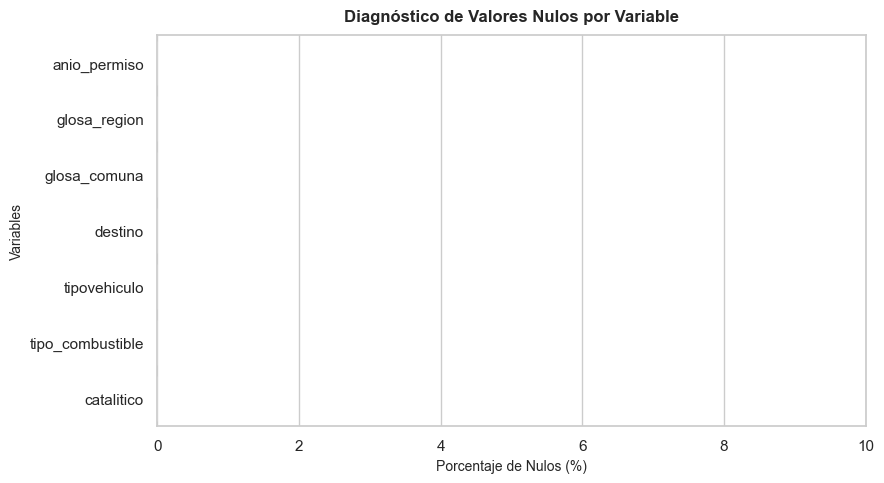

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual similar a Seaborn whitegrid
sns.set_theme(style="whitegrid")

# 1. Calcular el porcentaje de nulos para cada columna
porcentaje_nulos = (df_desagregado.isnull().sum() / len(df_desagregado)) * 100

# 2. Definir el tamaño de la figura
plt.figure(figsize=(9, 5))

# 3. Crear el gráfico de barras horizontal
ax = sns.barplot(
    x=porcentaje_nulos.values,
    y=porcentaje_nulos.index,
    color="steelblue"
)

# 4. Personalizar títulos y etiquetas
plt.title("Diagnóstico de Valores Nulos por Variable", fontsize=12, fontweight='bold', pad=10)
plt.xlabel("Porcentaje de Nulos (%)", fontsize=10)
plt.ylabel("Variables", fontsize=10)

plt.xlim(0, 10)

plt.tight_layout()
plt.show()

C:\Users\tablo\AppData\Local\Temp\ipykernel_1548\2897982185.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


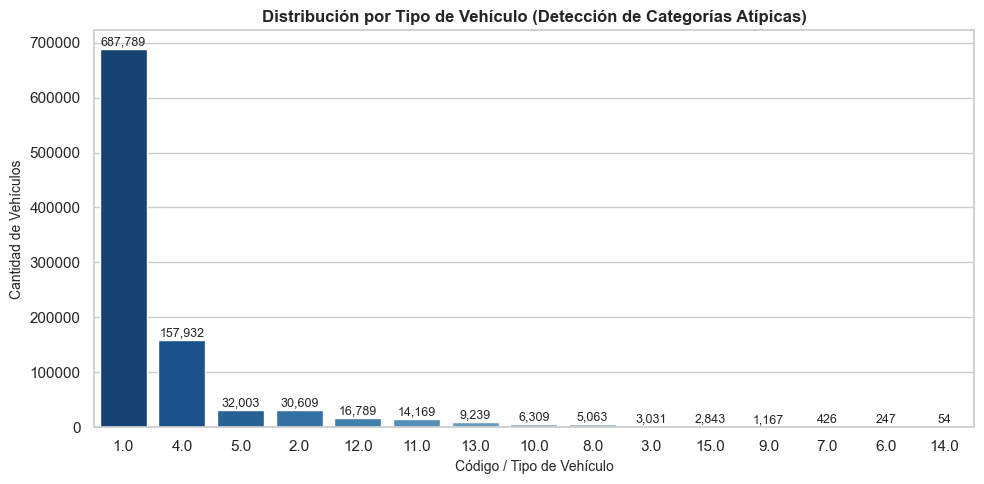

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Conteo por tipo de vehículo
ax = sns.countplot(
    data=df_desagregado,
    x='tipovehiculo',
    palette='Blues_r',
    order=df_desagregado['tipovehiculo'].value_counts().index
)

plt.title("Distribución por Tipo de Vehículo (Detección de Categorías Atípicas)", fontsize=12, fontweight='bold')
plt.xlabel("Código / Tipo de Vehículo", fontsize=10)
plt.ylabel("Cantidad de Vehículos", fontsize=10)

# Mostrar totales
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()